# 习题三

## 3.1 求下列积分的符号解

$$
(1)\int_0^1 \sqrt{1+4x} dx; \qquad (2)\int_0^{+\infty} e^{-x} \sin x dx.
$$

In [1]:
# 导入sympy库
import sympy as sp
# 导入 Jupyter 的显示控制库
from IPython.display import display, Math

# 定义符号变量
x = sp.symbols('x')
f1 = sp.sqrt(1+4*x)
f2 = sp.exp(-x)*sp.sin(x)

# 求解定积分符号解
I1 = sp.integrate(f1, (x, 0, 1))
I2 = sp.integrate(f2, (x, 0, sp.oo))

# 将 Sympy 结果转化为 latex 格式
latex_I1 = sp.latex(I1)
latex_I2 = sp.latex(I2)

# 渲染结果
display(Math(f'I_1 = {latex_I1}'))
display(Math(f'I_2 = {latex_I2}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3.2 求方程的符号解和数值解

$$
x^3 - 4x^2 + 6x - 8 = 0
$$

In [4]:
# 符号解
import sympy as sp

x = sp.symbols('x')
f = x**3 - 4*x**2 + 6*x - 8

# x^3 存在三个解
s1, s2, s3 = sp.solve(f, x)
latex_s1, latex_s2, latex_s3 = sp.latex(s1), sp.latex(s2), sp.latex(s3)

display(Math(f'x_1 = {latex_s1}'))
display(Math(f'x_2 = {latex_s2}'))
display(Math(f'x_3 = {latex_s3} = {s3.evalf()}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

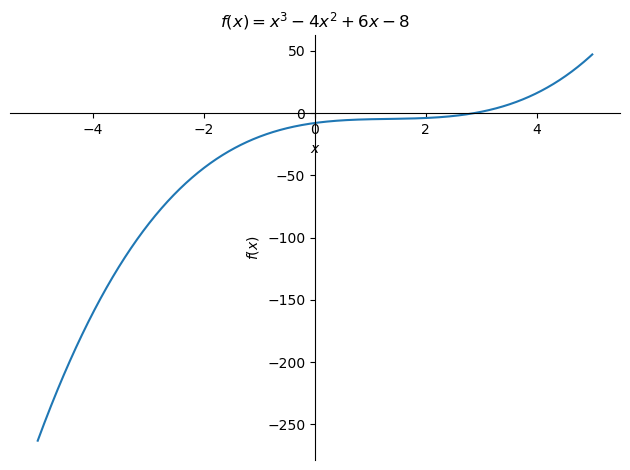

In [5]:
# 使用 Sympy 进行简单的画图分析
p = sp.plot(f, (x, -5, 5), title=r"$f(x) = x^3 - 4x^2 + 6x - 8$")

In [6]:
import numpy as np
from scipy.optimize import fsolve

# 1. 把方程定义为一个 Python 函数 (将等式一端化为 0)
def function(x):
    return x**3 - 4*x**2 + 6*x - 8

# 2. 提供一个初始猜测值 (这里体现了通用工具的代价)
# 通过上图，猜测根大概在 2.5 附近
initial_guess = 2.5

# 3. 调用 fsolve 黑盒求解
solution = fsolve(function, initial_guess)

print(f"数值解为: {solution[0]}")

数值解为: 2.881239401076398


## 3.3 求方程组的符号解和数值解

$$
\begin{cases}
x^2 - y - x = 3 \\
x + 3y = 6
\end{cases}
$$

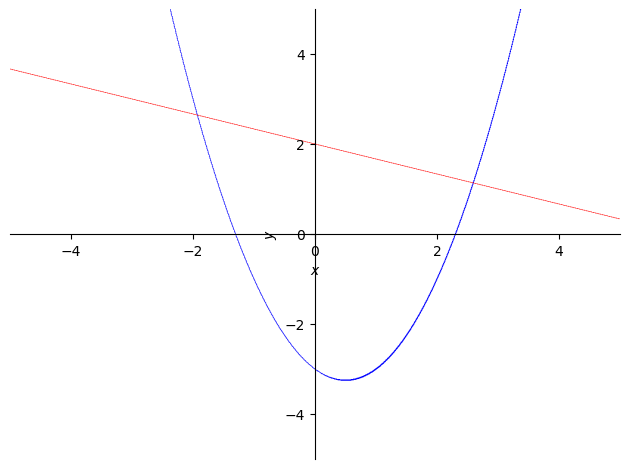

In [13]:
import sympy as sp
# 必须单独导入隐函数绘图模块
from sympy import plot_implicit, Eq

x, y = sp.symbols('x y')

# 必须用 Eq(表达式, 0) 来严格定义等式
eq1 = Eq(x**2 - y - x - 3, 0)
eq2 = Eq(x + 3*y - 6, 0)

# 分别画出两个隐函数图像，先不显示 (show=False)
p1 = plot_implicit(eq1, (x, -5, 5), (y, -5, 5), show=False, line_color='blue')
p2 = plot_implicit(eq2, (x, -5, 5), (y, -5, 5), show=False, line_color='red')

# 把第二个图“叠加”到第一个图上
p1.extend(p2)

# 最后统一显示
p1.show()

In [20]:
for i, s in enumerate(solutions, start=1):
    # 注意这里的 s_{i}，下划线是为了在 LaTeX 中显示为下标
    display(Math(f's_{i} = ({sp.latex(s[x])}, {sp.latex(s[y])}) = ({s[x].evalf()}, {s[y].evalf()})'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [19]:
import numpy as np
from scipy.optimize import fsolve

# 1. 按照 fsolve 的规矩定义函数
def equations(vars):
    # 第一步：拆包输入。把列表里的两个元素分别赋给 x 和 y
    x, y = vars 
    
    # 第二步：将方程化为 "= 0" 的形式
    # 原方程 1: x^2 - y - x = 3  =>  x^2 - y - x - 3 = 0
    eq1 = x**2 - y - x - 3
    # 原方程 2: x + 3y = 6       =>  x + 3y - 6 = 0
    eq2 = x + 3*y - 6
    
    # 第三步：打包输出。返回这些表达式的列表
    return [eq1, eq2]

# 2. 提供初始猜测值
# 因为之前通过精确解（或画图）知道有两个交点，我们给两组不同的初始值去“抓”这两个解
guess_A = [2, 1]   # 猜测第一个点在第一象限附近
guess_B = [-2, 3]  # 猜测第二个点在第二象限附近

# 3. 调用黑盒求解
solution_A = fsolve(equations, guess_A)
solution_B = fsolve(equations, guess_B)

print(f"靠近 {guess_A} 的数值解为: x = {solution_A[0]:.4f}, y = {solution_A[1]:.4f}")
print(f"靠近 {guess_B} 的数值解为: x = {solution_B[0]:.4f}, y = {solution_B[1]:.4f}")

靠近 [2, 1] 的数值解为: x = 2.5941, y = 1.1353
靠近 [-2, 3] 的数值解为: x = -1.9274, y = 2.6425


## 3.4 求边值问题的符号解

$$
y^{\prime\prime} + y = x \cos 2x,\, y(0) = 1,\, y(2) = 3
$$

In [25]:
import sympy as sp

x = sp.symbols('x')
y = sp.Function('y')(x)

eq = sp.Eq(y.diff(x, 2) + y, x*sp.cos(2*x))
ics = {y.subs(x, 0): 1, y.subs(x, 2): 3}

solutions = sp.dsolve(eq, y, ics=ics)

display(solutions)

Eq(y(x), -x*cos(2*x)/3 + (6*cos(4) - 4*sin(4) - 9*cos(2) + 27)*sin(x)/(9*sin(2)) + 4*sin(2*x)/9 + cos(x))

# 3.5 已知

$$
\mathbf{A}_1 = \begin{bmatrix}
1 & 2 \\
3 & 4 \\
5 & 6
\end{bmatrix}
,
\mathbf{A}_1 = \begin{bmatrix}
1 & 1 \\
2 & 2 \\
3 & 4
\end{bmatrix}
,
\mathbf{A}_3 = \begin{bmatrix}
2 & 6
\end{bmatrix}
,
\mathbf{A}_4 = \begin{bmatrix}
3 & 2
\end{bmatrix}
$$

利用 Python 分块矩阵的组合，求分块矩阵 $\displaystyle\mathbf{A} = \begin{bmatrix} \mathbf{A}_1 & \mathbf{A}_2 \\ \mathbf{A}_3 & \mathbf{A}_4 \end{bmatrix}$ 的行列式 $\det(\mathbf{A})$。

In [29]:
import numpy as np

A1 = np.array([[1, 2], [3, 4], [5, 6]])
A2 = np.array([[1, 1], [2, 2], [3, 4]])
A3 = np.array([[2, 6]])
A4 = np.array([[3, 2]])

A = np.block([[A1, A2], [A3, A4]])

det_A = np.linalg.det(A)

print(f"行列式为: {det_A} = {det_A:.2f}")

行列式为: -2.55351295663785e-16 = -0.00


## 3.6 求解下列线性方程组

$$
(1) 
\begin{cases}
x_1 + 2 x_2 + x_3 - x_4 = 0 \\
3 x_1 + 6 x_2 - x_3 - 3 x_4 = 0 \\
5 x_1 + 10 x_2 + x_3 - 5 x_4 = 0
\end{cases}
\qquad
(2)
\begin{cases}
2 x + y - z + w = 1 \\
4 x + 2 y - 2 z + w = 2 \\
2 x + y - z - w = 1
\end{cases}
$$